# 타이타닉호 성별 생존율 분석

웹에서 타이타닉 승객 데이터를 불러와 남성과 여성의 생존율을 비교합니다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rcParams

# Windows와 일반 Linux 환경에서 사용할 수 있는 한글 폰트를 순서대로 선택합니다.
font_candidates = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
selected_font = next((font for font in font_candidates if font in installed_fonts), 'DejaVu Sans')
rcParams['font.family'] = selected_font
rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font=selected_font)

print(f'사용 폰트: {selected_font}')

사용 폰트: Malgun Gothic


In [2]:
data_url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'
titanic = pd.read_csv(data_url)

print(f'데이터 크기: {titanic.shape[0]:,}행 x {titanic.shape[1]}열')
display(titanic.head())
display(titanic[['survived', 'sex']].describe(include='all'))

데이터 크기: 891행 x 15열


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


,survived,sex
count,891.000000,891
unique,NaN,2
top,NaN,male
freq,NaN,577
mean,0.383838,NaN
std,0.486592,NaN
min,0.000000,NaN
25%,0.000000,NaN
50%,0.000000,NaN
75%,1.000000,NaN


In [3]:
gender_summary = (
    titanic.groupby('sex', as_index=False)
    .agg(승객수=('survived', 'size'), 생존자수=('survived', 'sum'), 생존율=('survived', 'mean'))
    .assign(생존율=lambda frame: frame['생존율'] * 100)
    .replace({'sex': {'male': '남성', 'female': '여성'}})
)

gender_summary['생존율'] = gender_summary['생존율'].round(2)
display(gender_summary)

,sex,승객수,생존자수,생존율
0,여성,314,233,74.20
1,남성,577,109,18.89


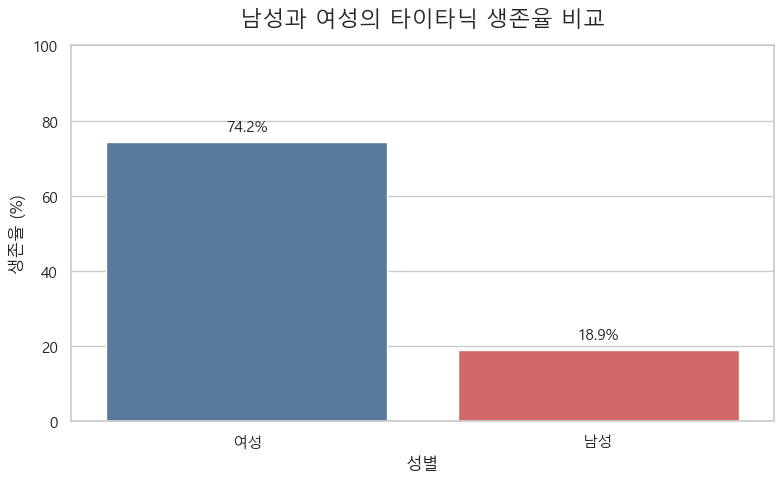

In [4]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=gender_summary, x='sex', y='생존율', hue='sex', palette=['#4C78A8', '#E45756'], legend=False)

ax.set_title('남성과 여성의 타이타닉 생존율 비교', fontsize=16, pad=14)
ax.set_xlabel('성별', fontsize=12)
ax.set_ylabel('생존율 (%)', fontsize=12)
ax.set_ylim(0, 100)

for bar, survival_rate in zip(ax.patches, gender_summary['생존율']):
    ax.annotate(f'{survival_rate:.1f}%',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=11, xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

## 분석 결과

성별별 생존율을 비교하면 여성의 생존율이 남성보다 높게 나타납니다. 위 표와 바차트의 실제 수치를 통해 두 집단의 생존율 차이를 확인할 수 있습니다.